In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------
# 1. Encoder
# ---------------------------
class Encoder(nn.Module):
    def __init__(self, in_ch=1, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, hidden, 4, 2, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


# ---------------------------
# 2. Vector Quantizer
# ---------------------------
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=512, embedding_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, z):
        B, C, H, W = z.shape
        z_flat = z.permute(0,2,3,1).contiguous().view(-1, C)

        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )

        indices = distances.argmin(dim=1)
        z_q = self.embedding(indices).view(B, H, W, C).permute(0,3,1,2)

        return z_q, indices


# ---------------------------
# 3. Decoder
# ---------------------------
class Decoder(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(hidden, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1)
        )

    def forward(self, z):
        return self.net(z)


# ---------------------------
# 4. Anomaly Simulation
# ---------------------------
def simulate_anomaly(z_q, codebook):
    mask = torch.rand_like(z_q[:, :1]) > 0.8  # random regions
    random_codes = codebook.embedding.weight[
        torch.randint(0, codebook.embedding.num_embeddings, (z_q.numel() // z_q.shape[1],))
    ].view_as(z_q)

    z_corrupt = torch.where(mask, random_codes, z_q)
    return z_corrupt, mask


# ---------------------------
# 5. Detection Head
# ---------------------------
class AnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, xg, xs):
        x = torch.cat([xg, xs], dim=1)
        return torch.sigmoid(self.net(x))


# ---------------------------
# Full Model
# ---------------------------
class AudDSRMock(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.vq = VectorQuantizer()
        self.decoder_general = Decoder()
        self.decoder_clean = Decoder()
        self.detector = AnomalyDetector()

    def forward(self, x):
        z = self.encoder(x)
        z_q, _ = self.vq(z)

        # simulate anomaly
        z_corr, mask = simulate_anomaly(z_q, self.vq)

        # reconstructions
        xg = self.decoder_general(z_q)     # original
        xs = self.decoder_clean(z_corr)   # cleaned

        # detection
        anomaly_map = self.detector(xg, xs)

        return anomaly_map, mask

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudDSRMock().to(device)
model.eval()

batch_size = 4
sample_input = torch.randn(batch_size, 1, 128, 128, device=device)

with torch.no_grad():
    anomaly_map, latent_mask = model(sample_input)

print(f"Device: {device}")
print(f"Input shape: {tuple(sample_input.shape)}")
print(f"Anomaly map shape: {tuple(anomaly_map.shape)}")
print(f"Latent mask shape: {tuple(latent_mask.shape)}")
print(
    "Anomaly map stats: "
    f"min={anomaly_map.min().item():.4f}, "
    f"max={anomaly_map.max().item():.4f}, "
    f"mean={anomaly_map.mean().item():.4f}"
)


Device: cpu
Input shape: (4, 1, 128, 128)
Anomaly map shape: (4, 1, 128, 128)
Latent mask shape: (4, 1, 32, 32)
Anomaly map stats: min=0.3746, max=0.5979, mean=0.4867


## Run The Model On The Entire Training Set

This section runs inference on all WAV files under the selected machine's training folder.

The workflow is:
- find every WAV file in train
- load each file, convert to mono, and resample to 16 kHz
- convert to a 128x128 log-mel spectrogram
- run the model for each file and compute an anomaly score
- report score statistics over the full training set
- visualize one selected file from that full-set run


In [34]:
import os
import numpy as np
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile

DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
MACHINE_TYPE = "bearing"
TARGET_SR = 16_000
N_MELS = 128
SPEC_SIZE = 128
VISUALIZE_INDEX = 0


def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def waveform_to_model_input(waveform, mel_transform):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0).unsqueeze(0)
    spec = F.interpolate(
        spec,
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    )
    return spec


mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=512,
    n_mels=N_MELS,
)

train_dir = os.path.join(DATA_ROOT, f"dev_{MACHINE_TYPE}", MACHINE_TYPE, "train")
wav_files = collect_wav_files(train_dir)
if not wav_files:
    raise FileNotFoundError(f"No WAV files found in {train_dir}")

if VISUALIZE_INDEX < 0 or VISUALIZE_INDEX >= len(wav_files):
    raise IndexError(f"VISUALIZE_INDEX must be in [0, {len(wav_files)-1}]")

model.eval()
anomaly_scores = []
selected_file = wav_files[VISUALIZE_INDEX]
selected_input = None
selected_anomaly_map = None
selected_latent_mask = None

with torch.no_grad():
    for idx, wav_path in enumerate(wav_files):
        waveform = load_waveform(wav_path)
        model_input = waveform_to_model_input(waveform, mel_transform).to(device)
        anomaly_map, latent_mask = model(model_input)

        # Scalar file-level score from the anomaly map
        anomaly_scores.append(float(anomaly_map.mean().item()))

        if idx == VISUALIZE_INDEX:
            selected_input = model_input.detach().cpu()
            selected_anomaly_map = anomaly_map.detach().cpu()
            selected_latent_mask = latent_mask.detach().cpu()

anomaly_scores = np.asarray(anomaly_scores, dtype=np.float32)

print(f"Processed files: {len(wav_files)}")
print(f"Selected file for plotting: {os.path.basename(selected_file)}")
print(
    "Anomaly score stats over full training set: "
    f"min={anomaly_scores.min():.4f}, "
    f"mean={anomaly_scores.mean():.4f}, "
    f"max={anomaly_scores.max():.4f}, "
    f"std={anomaly_scores.std():.4f}"
)

# Show top-5 highest-scoring files for quick inspection
ranked_idx = np.argsort(anomaly_scores)[::-1][:5]
print("Top-5 files by anomaly score:")
for rank, file_idx in enumerate(ranked_idx, start=1):
    print(f"{rank}. {os.path.basename(wav_files[file_idx])}  score={anomaly_scores[file_idx]:.4f}")


Processed files: 1000
Selected file for plotting: section_00_source_train_normal_0000_noAttribute.wav
Anomaly score stats over full training set: min=0.4931, mean=0.4939, max=0.4944, std=0.0002
Top-5 files by anomaly score:
1. section_00_source_train_normal_0765_noAttribute.wav  score=0.4944
2. section_00_source_train_normal_0313_noAttribute.wav  score=0.4944
3. section_00_source_train_normal_0003_noAttribute.wav  score=0.4944
4. section_00_source_train_normal_0483_noAttribute.wav  score=0.4944
5. section_00_source_train_normal_0581_noAttribute.wav  score=0.4944


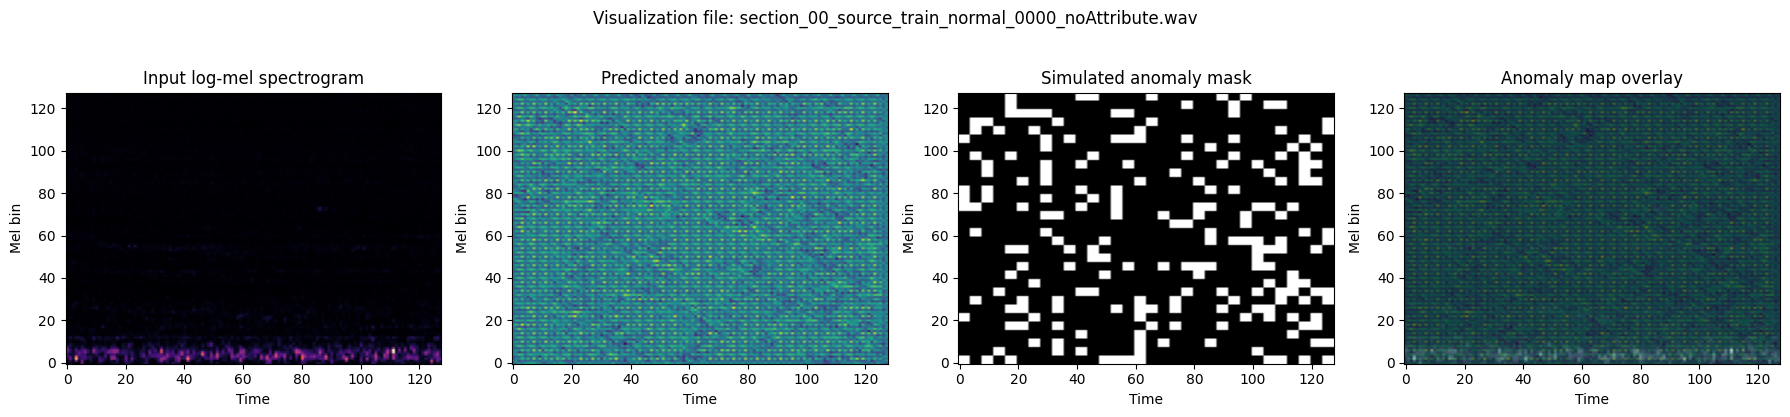

In [35]:
import matplotlib.pyplot as plt

input_image = selected_input.squeeze().numpy()
anomaly_image = selected_anomaly_map.squeeze().numpy()
mask_image = F.interpolate(
    selected_latent_mask.float(),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="nearest",
).squeeze().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(input_image, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Input log-mel spectrogram")

axes[1].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Predicted anomaly map")

axes[2].imshow(mask_image, origin="lower", aspect="auto", cmap="gray")
axes[2].set_title("Simulated anomaly mask")

axes[3].imshow(input_image, origin="lower", aspect="auto", cmap="gray")
axes[3].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis", alpha=0.5)
axes[3].set_title("Anomaly map overlay")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle(f"Visualization file: {os.path.basename(selected_file)}", y=1.03)
plt.tight_layout()
plt.show()


## Paper-Inspired Extension: Loss, Corruption, Detector, Frontend, and Evaluation

This section adds the requested modifications while keeping the earlier baseline cells untouched.

What is added:
1. A paper-style AE loss implementation matching the equation you shared.
2. Multiple latent corruption strategies (including contiguous block corruption).
3. Quantizer-capacity presets (small to very large) with a chosen default.
4. A detector head variant with optional encoder skip conditioning.
5. Frontend presets (STFT/mel/normalization) to test time-frequency tradeoffs.
6. Evaluation plots and metrics (histograms, thresholds, AUROC/pAUC when labels exist).

Important note:
- The exact paper architecture details (for example exact placement of `f1/f2`, `Q1/Q2`, and decoder wiring) were not fully specified in this notebook, so this is a faithful *paper-style approximation* of the loss structure and training flow.


In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Experiment options
# -----------------------------

# (4) Quantizer capacity options (plethora):
# - tiny: fast, but often underfits
# - base: good tradeoff
# - large/xlarge: higher capacity, potential overfit/memory pressure
QUANTIZER_OPTIONS = {
    "tiny":   {"q1_embeddings": 128,  "q2_embeddings": 128},
    "small":  {"q1_embeddings": 256,  "q2_embeddings": 256},
    "base":   {"q1_embeddings": 512,  "q2_embeddings": 512},
    "large":  {"q1_embeddings": 1024, "q2_embeddings": 1024},
    "xlarge": {"q1_embeddings": 2048, "q2_embeddings": 2048},
}
SELECTED_QUANTIZER = "base"

# (6) Frontend options:
# - transient: finer time resolution
# - balanced: balanced time/frequency resolution
# - harmonic: finer frequency resolution
FRONTEND_OPTIONS = {
    "transient": {"n_fft": 512,  "hop_length": 128, "n_mels": 128, "norm": "per_bin"},
    "balanced":  {"n_fft": 1024, "hop_length": 256, "n_mels": 128, "norm": "per_bin"},
    "harmonic":  {"n_fft": 2048, "hop_length": 512, "n_mels": 128, "norm": "global"},
    "low_compute": {"n_fft": 512, "hop_length": 256, "n_mels": 64, "norm": "none"},
}
SELECTED_FRONTEND = "balanced"

# (2) Corruption strategy options:
CORRUPTION_OPTIONS = {
    "point": {"mode": "point", "ratio": 0.20, "block_hw": (4, 4)},
    "time_stripe": {"mode": "time_stripe", "ratio": 0.20, "block_hw": (4, 16)},
    "freq_stripe": {"mode": "freq_stripe", "ratio": 0.20, "block_hw": (16, 4)},
    "block_small": {"mode": "block", "ratio": 0.20, "block_hw": (4, 4)},
    "block_medium": {"mode": "block", "ratio": 0.20, "block_hw": (8, 8)},
    "block_large": {"mode": "block", "ratio": 0.20, "block_hw": (12, 12)},
}
SELECTED_CORRUPTION = "block_medium"

# (5) Detector presets with optional encoder skip conditioning.
DETECTOR_OPTIONS = {
    "light": {"width": 32, "use_skip": False},
    "skip_light": {"width": 32, "use_skip": True},
    "skip_wide": {"width": 64, "use_skip": True},
}
SELECTED_DETECTOR = "skip_light"

# Paths and runtime settings
DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
MACHINE_TYPE = "bearing"
TARGET_SR = 16_000
SPEC_SIZE = 128
BATCH_SIZE = 16
TRAIN_EPOCHS = 1   # increase after smoke test
LR = 1e-3
VISUALIZE_INDEX = 0
TOPK_RATIO = 0.05  # file-level score = mean of top 5% anomaly-map pixels

# (1) Paper-style loss weights
LAMBDA_X = 1.0
LAMBDA_K = 0.25

# Extra detector-supervision weight (not part of your Eq. 1, added intentionally)
LAMBDA_DET = 0.5

q_cfg = QUANTIZER_OPTIONS[SELECTED_QUANTIZER]
f_cfg = FRONTEND_OPTIONS[SELECTED_FRONTEND]
c_cfg = CORRUPTION_OPTIONS[SELECTED_CORRUPTION]
d_cfg = DETECTOR_OPTIONS[SELECTED_DETECTOR]

print("Selected options:")
print(f"- quantizer: {SELECTED_QUANTIZER} -> {q_cfg}")
print(f"- frontend:  {SELECTED_FRONTEND} -> {f_cfg}")
print(f"- corruption:{SELECTED_CORRUPTION} -> {c_cfg}")
print(f"- detector:  {SELECTED_DETECTOR} -> {d_cfg}")


Selected options:
- quantizer: base -> {'q1_embeddings': 512, 'q2_embeddings': 512}
- frontend:  balanced -> {'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'norm': 'per_bin'}
- corruption:block_medium -> {'mode': 'block', 'ratio': 0.2, 'block_hw': (8, 8)}
- detector:  skip_light -> {'width': 32, 'use_skip': True}


In [37]:
def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def normalize_spec(spec, mode):
    # spec shape: (1, n_mels, time)
    if mode == "none":
        return spec
    if mode == "global":
        mean = spec.mean()
        std = spec.std().clamp_min(1e-6)
        return (spec - mean) / std
    if mode == "per_bin":
        mean = spec.mean(dim=-1, keepdim=True)
        std = spec.std(dim=-1, keepdim=True).clamp_min(1e-6)
        return (spec - mean) / std
    raise ValueError(f"Unknown normalization mode: {mode}")


def build_mel_transform(frontend_cfg):
    return T.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=frontend_cfg["n_fft"],
        hop_length=frontend_cfg["hop_length"],
        n_mels=frontend_cfg["n_mels"],
    )


def waveform_to_model_input(waveform, mel_transform, frontend_cfg):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0)  # (1, n_mels, time)
    spec = normalize_spec(spec, frontend_cfg["norm"])
    spec = F.interpolate(
        spec.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)  # (1, H, W)
    return spec


class SpectrogramFileDataset(Dataset):
    def __init__(self, file_paths, mel_transform, frontend_cfg):
        self.file_paths = file_paths
        self.mel_transform = mel_transform
        self.frontend_cfg = frontend_cfg

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = load_waveform(file_path)
        spec = waveform_to_model_input(waveform, self.mel_transform, self.frontend_cfg)
        return spec, file_path


def make_corruption_mask(z_q, mode="block", ratio=0.2, block_hw=(8, 8)):
    bsz, _, h, w = z_q.shape
    mask = torch.zeros((bsz, 1, h, w), device=z_q.device, dtype=torch.bool)

    if mode == "point":
        return torch.rand((bsz, 1, h, w), device=z_q.device) < ratio

    if mode == "time_stripe":
        stripe_w = max(1, int(w * ratio))
        for b in range(bsz):
            start_w = torch.randint(0, max(1, w - stripe_w + 1), (1,), device=z_q.device).item()
            mask[b, :, :, start_w : start_w + stripe_w] = True
        return mask

    if mode == "freq_stripe":
        stripe_h = max(1, int(h * ratio))
        for b in range(bsz):
            start_h = torch.randint(0, max(1, h - stripe_h + 1), (1,), device=z_q.device).item()
            mask[b, :, start_h : start_h + stripe_h, :] = True
        return mask

    if mode == "block":
        block_h, block_w = block_hw
        target_area = max(1, int(ratio * h * w))
        block_area = max(1, block_h * block_w)
        num_blocks = max(1, target_area // block_area)

        for b in range(bsz):
            for _ in range(num_blocks):
                top = torch.randint(0, max(1, h - block_h + 1), (1,), device=z_q.device).item()
                left = torch.randint(0, max(1, w - block_w + 1), (1,), device=z_q.device).item()
                mask[b, :, top : top + block_h, left : left + block_w] = True
        return mask

    raise ValueError(f"Unknown corruption mode: {mode}")


In [38]:
class HierarchicalEncoder(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, ch1, 4, 2, 1)   # 128 -> 64
        self.conv2 = nn.Conv2d(ch1, ch2, 4, 2, 1)     # 64 -> 32
        self.act = nn.ReLU()

    def forward(self, x):
        f1 = self.act(self.conv1(x))
        f2 = self.act(self.conv2(f1))
        return f1, f2


class VectorQuantizerSimple(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, z):
        bsz, ch, h, w = z.shape
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, ch)

        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )

        indices = distances.argmin(dim=1)
        z_q = self.embedding(indices).view(bsz, h, w, ch).permute(0, 3, 1, 2)
        return z_q, indices


class HierarchicalDecoder(nn.Module):
    def __init__(self, ch1=64, ch2=128):
        super().__init__()
        self.up_f2 = nn.ConvTranspose2d(ch2, ch1, 4, 2, 1)     # 32 -> 64
        self.fuse = nn.Sequential(
            nn.Conv2d(ch1 * 2, ch1, 3, padding=1),
            nn.ReLU(),
        )
        self.to_img = nn.Sequential(
            nn.ConvTranspose2d(ch1, 32, 4, 2, 1),              # 64 -> 128
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
        )

    def forward(self, q2, q1):
        f2_up = self.up_f2(q1)
        fused = self.fuse(torch.cat([q2, f2_up], dim=1))
        out = self.to_img(fused)
        return out


class EnhancedAnomalyDetector(nn.Module):
    def __init__(self, width=32, use_skip=True, skip_ch=64):
        super().__init__()
        self.use_skip = use_skip
        in_ch = 3 + (1 if use_skip else 0)  # xg, xs, |xg-xs|, optional encoder skip

        self.skip_proj = nn.Conv2d(skip_ch, 1, 1) if use_skip else None
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, width, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, 1, 1),
        )

    def forward(self, xg, xs, skip_feat=None):
        feats = [xg, xs, torch.abs(xg - xs)]

        if self.use_skip:
            if skip_feat is None:
                raise ValueError("use_skip=True but skip_feat was not provided")
            skip = self.skip_proj(skip_feat)
            skip = F.interpolate(skip, size=xg.shape[-2:], mode="bilinear", align_corners=False)
            feats.append(skip)

        x = torch.cat(feats, dim=1)
        return torch.sigmoid(self.net(x))


class AudDSRPaperLike(nn.Module):
    def __init__(self, ch1=64, ch2=128, q1_embeddings=512, q2_embeddings=512,
                 corruption_cfg=None, detector_cfg=None):
        super().__init__()
        self.encoder = HierarchicalEncoder(in_ch=1, ch1=ch1, ch2=ch2)
        self.q1 = VectorQuantizerSimple(num_embeddings=q1_embeddings, embedding_dim=ch2)  # for f2
        self.q2 = VectorQuantizerSimple(num_embeddings=q2_embeddings, embedding_dim=ch1)  # for f1

        self.decoder_general = HierarchicalDecoder(ch1=ch1, ch2=ch2)
        self.decoder_clean = HierarchicalDecoder(ch1=ch1, ch2=ch2)

        detector_cfg = detector_cfg or {"width": 32, "use_skip": True}
        self.detector = EnhancedAnomalyDetector(
            width=detector_cfg["width"],
            use_skip=detector_cfg["use_skip"],
            skip_ch=ch1,
        )

        self.corruption_cfg = corruption_cfg or {"mode": "block", "ratio": 0.2, "block_hw": (8, 8)}

    def forward(self, x):
        f1, f2 = self.encoder(x)

        q1, _ = self.q1(f2)
        q2, _ = self.q2(f1)

        mask = make_corruption_mask(
            q1,
            mode=self.corruption_cfg["mode"],
            ratio=self.corruption_cfg["ratio"],
            block_hw=self.corruption_cfg["block_hw"],
        )

        random_idx = torch.randint(0, self.q1.embedding.num_embeddings, (q1.shape[0], q1.shape[2], q1.shape[3]), device=q1.device)
        random_codes = self.q1.embedding.weight[random_idx.view(-1)].view(q1.shape[0], q1.shape[2], q1.shape[3], q1.shape[1]).permute(0, 3, 1, 2)
        q1_corrupt = torch.where(mask.expand_as(q1), random_codes, q1)

        x_general = self.decoder_general(q2, q1)
        x_clean = self.decoder_clean(q2, q1_corrupt)

        anomaly_map = self.detector(
            x_general,
            x_clean,
            skip_feat=f1 if self.detector.use_skip else None,
        )

        return {
            "x_out": x_general,
            "x_clean": x_clean,
            "anomaly_map": anomaly_map,
            "mask": mask,
            "f1": f1,
            "f2": f2,
            "q1": q1,
            "q2": q2,
        }


def paper_ae_loss(x, outputs, lambda_x=1.0, lambda_k=0.25, lambda_det=0.0):
    # (1) Paper-style AE loss from your equation:
    # Lae = λx L2(X, Xout)
    #     + L2(sg[f2], Q1) + λK L2(f2, sg[Q1])
    #     + L2(sg[f1], Q2) + λK L2(f1, sg[Q2])
    rec = F.mse_loss(outputs["x_out"], x)

    q1_codebook = F.mse_loss(outputs["f2"].detach(), outputs["q1"])
    q1_commit = F.mse_loss(outputs["f2"], outputs["q1"].detach())

    q2_codebook = F.mse_loss(outputs["f1"].detach(), outputs["q2"])
    q2_commit = F.mse_loss(outputs["f1"], outputs["q2"].detach())

    ae_loss = (
        lambda_x * rec
        + q1_codebook + lambda_k * q1_commit
        + q2_codebook + lambda_k * q2_commit
    )

    # Extra detection supervision (not in Eq. 1, optional extension)
    det_target = F.interpolate(outputs["mask"].float(), size=x.shape[-2:], mode="nearest")
    det_loss = F.binary_cross_entropy(outputs["anomaly_map"], det_target)

    total = ae_loss + lambda_det * det_loss

    return total, {
        "total": float(total.item()),
        "ae": float(ae_loss.item()),
        "rec": float(rec.item()),
        "q1_cb": float(q1_codebook.item()),
        "q1_cm": float(q1_commit.item()),
        "q2_cb": float(q2_codebook.item()),
        "q2_cm": float(q2_commit.item()),
        "det": float(det_loss.item()),
    }


In [39]:
mel_transform_v2 = build_mel_transform(f_cfg)

train_dir_v2 = os.path.join(DATA_ROOT, f"dev_{MACHINE_TYPE}", MACHINE_TYPE, "train")
train_files_v2 = collect_wav_files(train_dir_v2)
if len(train_files_v2) == 0:
    raise FileNotFoundError(f"No WAV files found in: {train_dir_v2}")

train_dataset_v2 = SpectrogramFileDataset(train_files_v2, mel_transform_v2, f_cfg)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

paper_model = AudDSRPaperLike(
    ch1=64,
    ch2=128,
    q1_embeddings=q_cfg["q1_embeddings"],
    q2_embeddings=q_cfg["q2_embeddings"],
    corruption_cfg=c_cfg,
    detector_cfg=d_cfg,
).to(device)

optimizer_v2 = torch.optim.Adam(paper_model.parameters(), lr=LR)

print(f"Training files: {len(train_files_v2)}")
print(f"Batches per epoch: {len(train_loader_v2)}")

paper_model.train()
for epoch in range(1, TRAIN_EPOCHS + 1):
    running = {"total": 0.0, "ae": 0.0, "rec": 0.0, "det": 0.0}

    for batch in train_loader_v2:
        x = batch[0].to(device)   # batch[1] contains file paths

        optimizer_v2.zero_grad()
        outputs = paper_model(x)
        loss, parts = paper_ae_loss(
            x,
            outputs,
            lambda_x=LAMBDA_X,
            lambda_k=LAMBDA_K,
            lambda_det=LAMBDA_DET,
        )
        loss.backward()
        optimizer_v2.step()

        running["total"] += parts["total"]
        running["ae"] += parts["ae"]
        running["rec"] += parts["rec"]
        running["det"] += parts["det"]

    n_batches = max(1, len(train_loader_v2))
    print(
        f"Epoch {epoch}/{TRAIN_EPOCHS} | "
        f"total={running['total']/n_batches:.4f} | "
        f"ae={running['ae']/n_batches:.4f} | "
        f"rec={running['rec']/n_batches:.4f} | "
        f"det={running['det']/n_batches:.4f}"
    )

print("Paper-like training pass complete.")


Training files: 1000
Batches per epoch: 63
Epoch 1/1 | total=1.9523 | ae=1.8532 | rec=0.5904 | det=0.1982
Paper-like training pass complete.


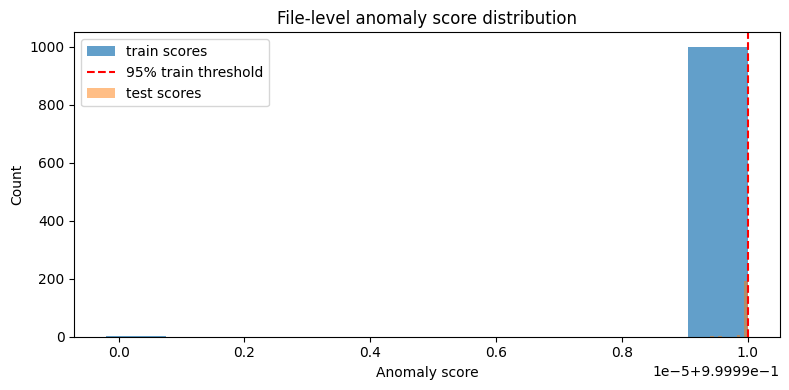

In [42]:
# Plot score histograms
plt.figure(figsize=(8, 4))
plt.hist(x=train_scores_v2, bins="auto", alpha=0.7, label="train scores")
plt.axvline(x=train_threshold, color="red", linestyle="--", label="95% train threshold")

if test_scores_v2 is not None:
    plt.hist(x=test_scores_v2, bins="auto", alpha=0.5, label="test scores")

plt.title("File-level anomaly score distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

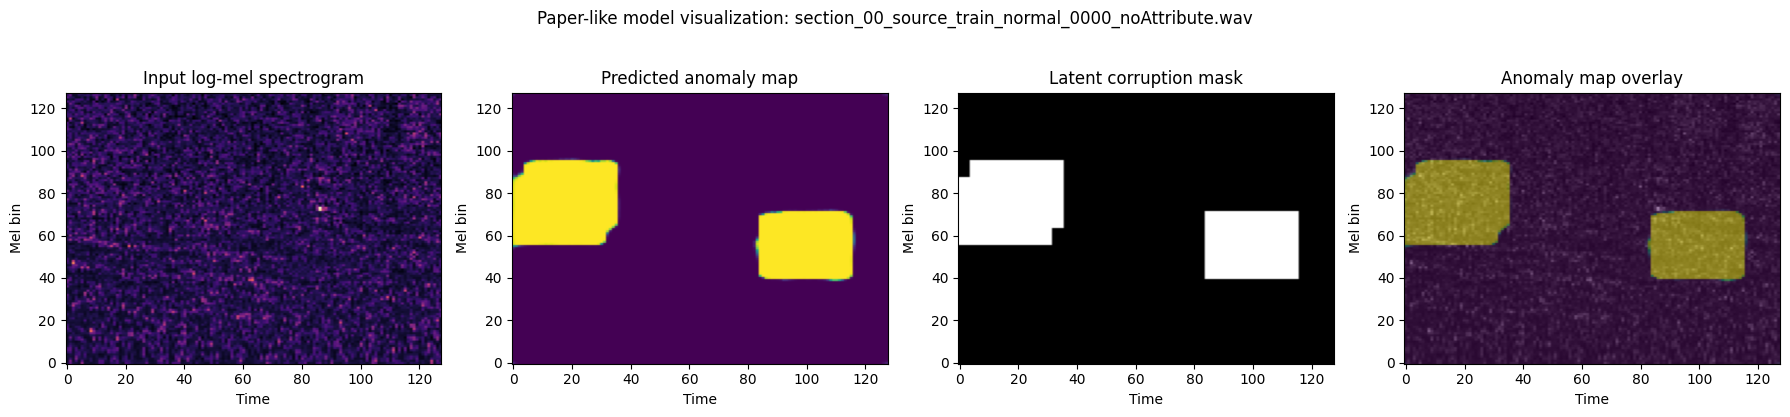

In [ ]:
# Visualize one file from the paper-like pipeline
if VISUALIZE_INDEX < 0 or VISUALIZE_INDEX >= len(train_files_v2):
    raise IndexError(f"VISUALIZE_INDEX must be in [0, {len(train_files_v2)-1}]")

paper_selected_file = train_files_v2[VISUALIZE_INDEX]
paper_selected_waveform = load_waveform(paper_selected_file)
paper_selected_input = waveform_to_model_input(paper_selected_waveform, mel_transform_v2, f_cfg).unsqueeze(0).to(device)

paper_model.eval()
with torch.no_grad():
    paper_out = paper_model(paper_selected_input)

paper_input_img = paper_selected_input.squeeze().detach().cpu().numpy()
paper_map_img = paper_out["anomaly_map"].squeeze().detach().cpu().numpy()
paper_mask_img = F.interpolate(
    paper_out["mask"].float(),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="nearest",
).squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(paper_input_img, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Input log-mel spectrogram")

axes[1].imshow(paper_map_img, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Predicted anomaly map")

axes[2].imshow(paper_mask_img, origin="lower", aspect="auto", cmap="gray")
axes[2].set_title("Latent corruption mask")

axes[3].imshow(paper_input_img, origin="lower", aspect="auto", cmap="gray")
axes[3].imshow(paper_map_img, origin="lower", aspect="auto", cmap="viridis", alpha=0.5)
axes[3].set_title("Anomaly map overlay")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle(f"Paper-like model visualization: {os.path.basename(paper_selected_file)}", y=1.03)
plt.tight_layout()
plt.show()
